# Linear probe — per-class test metrics

Bar plots of the embeddings-stage linear probe's **per-class** PR-AUC and F1 on the
test set, pulled straight from MLflow (`linear_probe_test_*` metrics on the nested
`embeddings_fold*` run). Per-class test support is read from the fold's embeddings
HDF5 when it's reachable — PR-AUC's baseline is the class prevalence, so the counts
belong next to the scores.

The second chart compares our per-class **PR-AUC** against published values
(`PAPER_PR_AUC`). Edit `RUN_NAME` (or set `RUN_ID`) / `PAPER_PR_AUC` and run all.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np

TRACKING_URI = "http://localhost:8989"
RUN_NAME = "supervised_reproduce_k_palmer__resnet18_full_train"
RUN_ID = None            # set to a parent run id to override RUN_NAME

# Published per-class PR-AUC / average precision to compare against.
PAPER_PR_AUC = {"SRKW": 0.970, "TKW": 0.756, "HW": 0.972}
PAPER_LABEL = "paper"

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT_DIR = REPO_ROOT / "data/experiment_runs"

# Okabe–Ito: colourblind-safe, fixed order, one hue per series (never cycled).
METRIC_COLORS = {"pr_auc": "#0072B2", "f1": "#E69F00"}
METRIC_LABELS = {"pr_auc": "PR-AUC", "f1": "F1"}
PAPER_COLOR = "#555555"
INK, MUTED, GRID = "#1a1a1a", "#6b6b6b", "#d9d9d9"

mlflow.set_tracking_uri(TRACKING_URI)
client = mlflow.tracking.MlflowClient()

In [2]:
def find_probe_runs(run_name, run_id=None):
    """The nested embeddings_fold* runs for the named (or given) parent run,
    newest run per fold, ordered by fold."""
    if run_id:
        parent = client.get_run(run_id)
    else:
        hits = [
            r
            for exp in client.search_experiments()
            for r in client.search_runs([exp.experiment_id], f"tags.`mlflow.runName` = '{run_name}'")
        ]
        if not hits:
            raise SystemExit(f"no MLflow run named {run_name!r} under {mlflow.get_tracking_uri()}")
        parent = max(hits, key=lambda r: r.info.start_time)

    children = client.search_runs(
        [parent.info.experiment_id], f"tags.`mlflow.parentRunId` = '{parent.info.run_id}'"
    )
    latest = {}  # newest run wins per fold, so reruns supersede
    for r in children:
        name = r.data.tags.get("mlflow.runName", "")
        if not name.startswith("embeddings_fold"):
            continue
        fold = int(name.removeprefix("embeddings_fold"))
        if fold not in latest or r.info.start_time > latest[fold].info.start_time:
            latest[fold] = r
    if not latest:
        raise SystemExit(f"parent run {parent.info.run_id} has no embeddings_fold* child runs")
    return parent, [latest[f] for f in sorted(latest)]


def parse_metrics(metrics):
    """(class order, {metric: {class: value}}, {metric: macro value}) from a
    run's linear_probe_test_* metrics."""
    per_class = {m: {} for m in METRIC_COLORS}
    macro = {}
    for metric in METRIC_COLORS:
        macro[metric] = metrics[f"linear_probe_test_{metric}"]
        pattern = re.compile(rf"^linear_probe_test_{metric}_(.+)$")
        for key, value in metrics.items():
            if (match := pattern.match(key)) is not None:
                per_class[metric][match.group(1)] = value
    return sorted(per_class["pr_auc"]), per_class, macro


def class_support(run, classes):
    """Test-set count per class from the fold's embeddings HDF5 (label ints index
    sorted(classes)). None if the file isn't reachable from here."""
    rel = run.data.params.get("embeddings_path")
    if not rel:
        return None
    path = next((p for p in (Path(rel), REPO_ROOT / rel) if p.exists()), None)
    if path is None:
        return None
    import h5py

    with h5py.File(path, "r") as h5:
        if "test_labels" not in h5:
            return None
        labels = h5["test_labels"][:]
    counts = np.bincount(labels, minlength=len(classes))
    return {name: int(counts[i]) for i, name in enumerate(sorted(classes))}

In [3]:
parent, folds = find_probe_runs(RUN_NAME, RUN_ID)
name = parent.data.tags.get("mlflow.runName", parent.info.run_id)

data = []
for run in folds:
    fold = int(run.data.tags["mlflow.runName"].removeprefix("embeddings_fold"))
    classes, per_class, macro = parse_metrics(run.data.metrics)
    support = class_support(run, classes)
    data.append((fold, classes, per_class, macro, support))
    for metric in METRIC_COLORS:
        row = "  ".join(f"{c}={per_class[metric][c]:.3f}" for c in classes)
        print(f"fold{fold} {METRIC_LABELS[metric]:6s} macro={macro[metric]:.3f} | {row}")
    if support:
        print(f"fold{fold} test support  | " + "  ".join(f"{c}={support[c]:,}" for c in classes))
    shared = [c for c in classes if c in PAPER_PR_AUC]
    if shared:
        print(f"fold{fold} PR-AUC vs {PAPER_LABEL:>6s} | " + "  ".join(
            f"{c}: {per_class['pr_auc'][c]:.3f} vs {PAPER_PR_AUC[c]:.3f} (Δ{per_class['pr_auc'][c]-PAPER_PR_AUC[c]:+.3f})"
            for c in shared))

fold0 PR-AUC macro=0.970 | Background=0.968  HW=0.998  SRKW=0.992  TKW=0.922
fold0 F1     macro=0.937 | Background=0.924  HW=0.984  SRKW=0.972  TKW=0.869
fold0 test support  | Background=4,417  HW=25,071  SRKW=3,900  TKW=1,369
fold0 PR-AUC vs  paper | HW: 0.998 vs 0.972 (Δ+0.026)  SRKW: 0.992 vs 0.970 (Δ+0.022)  TKW: 0.922 vs 0.756 (Δ+0.166)


In [4]:
def plot_fold(classes, per_class, macro, support, fold, title):
    """Grouped bars: per-class PR-AUC and F1, each with its macro mean as a
    dashed reference line (value in the legend); a test-support panel below when
    counts are available."""
    metrics = list(METRIC_COLORS)
    x = np.arange(len(classes))
    width = 0.38

    nrows = 2 if support else 1
    fig, axes = plt.subplots(
        nrows, 1, figsize=(1.7 * len(classes) + 3, 5.0 if support else 3.8),
        sharex=True, layout="constrained",
        gridspec_kw={"height_ratios": [3, 1.1][:nrows]},
    )
    ax = axes[0] if support else axes

    for i, metric in enumerate(metrics):
        offset = (i - (len(metrics) - 1) / 2) * width
        values = [per_class[metric][c] for c in classes]
        bars = ax.bar(
            x + offset, values, width,
            label=f"{METRIC_LABELS[metric]}   (macro {macro[metric]:.3f})",
            color=METRIC_COLORS[metric], edgecolor="white", linewidth=0.6, zorder=3,
        )
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8.5, color=INK)
        ax.axhline(macro[metric], color=METRIC_COLORS[metric], lw=1.3, ls=(0, (5, 3)), zorder=2, alpha=0.9)

    ax.set_ylim(0, 1.28)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel("test score", color=INK, fontsize=10)
    ax.legend(frameon=False, ncol=len(metrics), loc="upper center", bbox_to_anchor=(0.5, 1.0), fontsize=9)
    ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelcolor=INK)

    if support:
        axs = axes[1]
        counts = [support[c] for c in classes]
        bars = axs.bar(x, counts, width * 1.6, color=MUTED, zorder=3)
        axs.bar_label(bars, fmt="{:,.0f}".format, padding=3, fontsize=8.5, color=INK)
        axs.set_ylabel("test clips", color=INK, fontsize=10)
        axs.set_ylim(0, max(counts) * 1.2)
        axs.set_yticks([])
        axs.grid(axis="y", color=GRID, lw=0.8, zorder=0)
        for side in ("top", "right", "left"):
            axs.spines[side].set_visible(False)
        axs.spines["bottom"].set_color(MUTED)
        axs.tick_params(colors=MUTED, labelcolor=INK)
        ax = axs

    ax.set_xticks(x)
    ax.set_xticklabels(classes, fontsize=10, color=INK)
    fig.suptitle(title, color=INK, fontsize=11, ha="left", x=0.012)
    return fig


def plot_paper_comparison(classes, per_class, paper, fold, title):
    """Per-class PR-AUC, ours vs a published value, for the classes both report."""
    shared = [c for c in classes if c in paper]
    if not shared:
        return None
    x = np.arange(len(shared))
    width = 0.36

    fig, ax = plt.subplots(figsize=(1.9 * len(shared) + 2.5, 4.0), layout="constrained")
    series = [("ours", [per_class["pr_auc"][c] for c in shared], METRIC_COLORS["pr_auc"]),
              (PAPER_LABEL, [paper[c] for c in shared], PAPER_COLOR)]
    for i, (label, values, color) in enumerate(series):
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, values, width, label=label, color=color,
                      edgecolor="white", linewidth=0.6, zorder=3)
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9, color=INK)

    for xi, c in enumerate(shared):
        delta = per_class["pr_auc"][c] - paper[c]
        top = max(per_class["pr_auc"][c], paper[c])
        ax.text(xi, top + 0.12, f"Δ {delta:+.3f}", ha="center", va="bottom",
                fontsize=9, color=INK, fontweight="bold")

    ax.set_ylim(0, 1.22)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel("test PR-AUC", color=INK, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(shared, fontsize=10, color=INK)
    ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.09), fontsize=9)
    ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelcolor=INK)
    fig.suptitle(title, color=INK, fontsize=11, ha="left", x=0.012)
    return fig

wrote /home/noah/HALLO_encoder_collection/data/experiment_runs/supervised_reproduce_k_palmer__resnet18_full_train__linear_probe_class_metrics_fold0.png
wrote /home/noah/HALLO_encoder_collection/data/experiment_runs/supervised_reproduce_k_palmer__resnet18_full_train__pr_auc_vs_paper_fold0.png


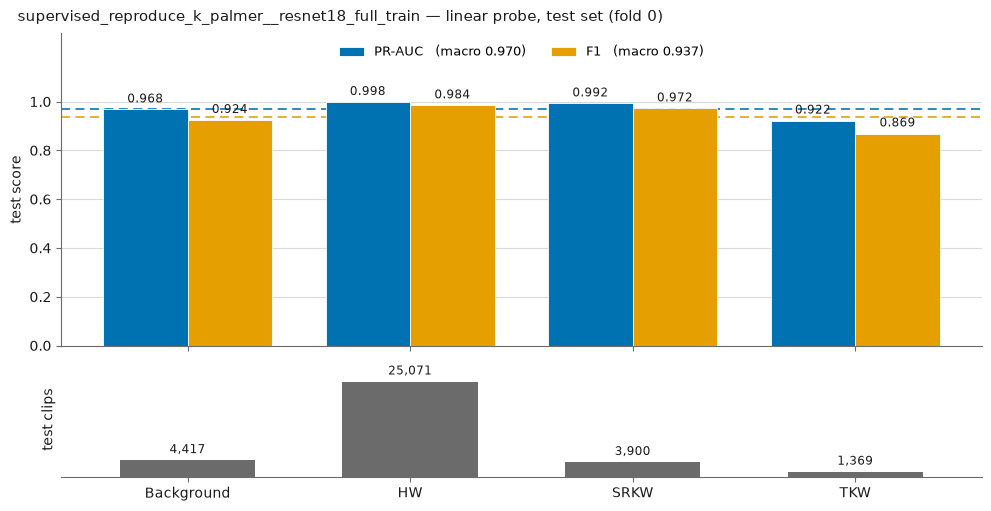

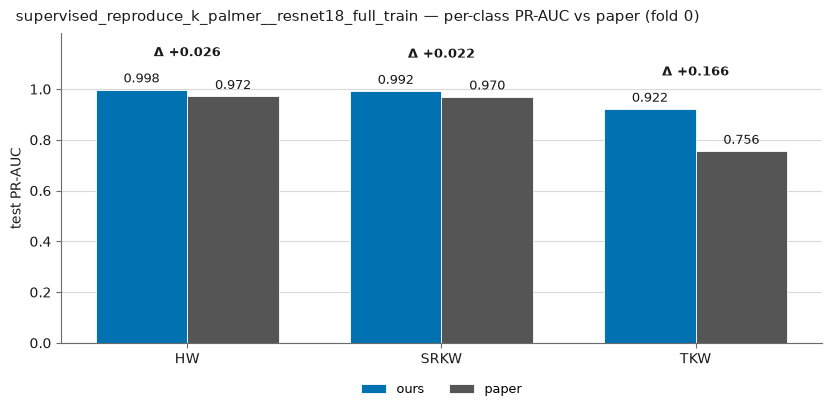

In [5]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
for fold, classes, per_class, macro, support in data:
    fig = plot_fold(classes, per_class, macro, support, fold,
                    f"{name} — linear probe, test set (fold {fold})")
    out = OUT_DIR / f"{name}__linear_probe_class_metrics_fold{fold}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"wrote {out}")

    cmp = plot_paper_comparison(classes, per_class, PAPER_PR_AUC, fold,
                                f"{name} — per-class PR-AUC vs {PAPER_LABEL} (fold {fold})")
    if cmp is not None:
        out = OUT_DIR / f"{name}__pr_auc_vs_{PAPER_LABEL}_fold{fold}.png"
        cmp.savefig(out, dpi=150, bbox_inches="tight")
        print(f"wrote {out}")
plt.show()